In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + np.random.randint(3)
reg = LinearRegression().fit(X, y)
reg.score(X, y)
reg.coef_
reg.intercept_
reg.predict(np.array([[3, 5]]))

array([15.])

In [3]:
y_hat = reg.predict(X)

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create data
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
y = np.dot(X, np.array([1, 2])) + 3

# Train the model
reg = LinearRegression().fit(X, y)

# Predict y_hat for the original X
y_hat = reg.predict(X)

# Create DataFrame for plotting
df = pd.DataFrame({'x0': X[:, 0], 'x1': X[:, 1], 'y': y, 'y_hat': y_hat})

df.head()

,x0,x1,y,y_hat
0,1,1,6,6.0
1,1,2,8,8.0
2,2,2,9,9.0
3,2,3,11,11.0


<Axes: >

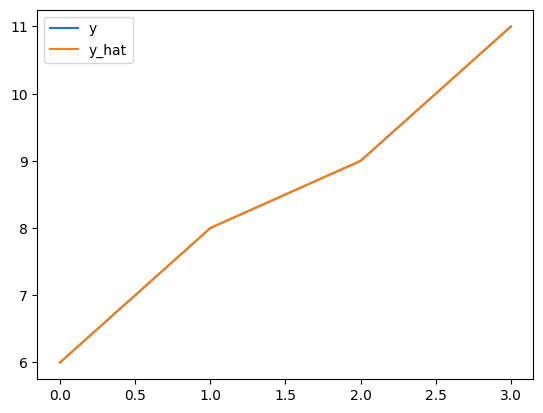

In [5]:
df[["y", "y_hat"]].plot()

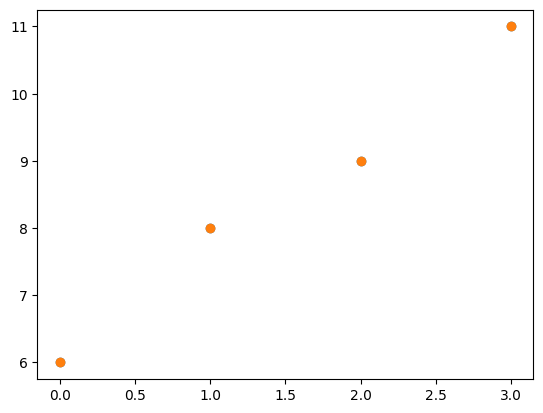

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(np.arange(len(y)), y)
plt.scatter(np.arange(len(y)), y_hat)
plt.show()

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("DataScience_salaries_2025.csv")

In [9]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


<Axes: xlabel='job_title'>

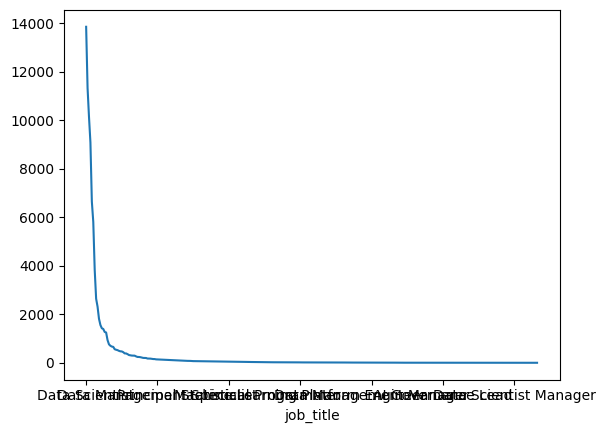

In [10]:
df["job_title"].value_counts().plot()

{'whiskers': [<matplotlib.lines.Line2D at 0x1db320b3ed0>,
 'caps': [<matplotlib.lines.Line2D at 0x1db320b3110>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db320b16d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1db320b2e90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db320b2d50>],
 'means': []}

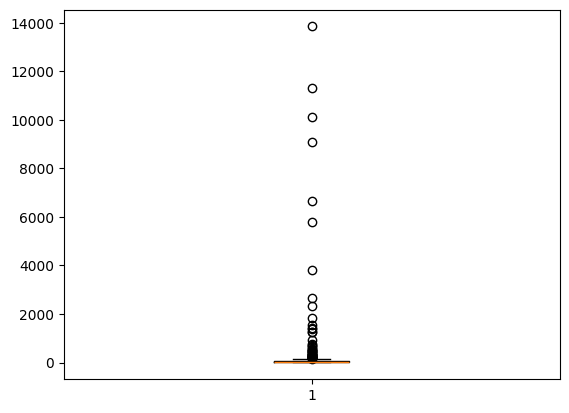

In [11]:
plt.boxplot(df["job_title"].value_counts().values)

In [12]:
jt_vc = df["job_title"].value_counts()
jt_vc = jt_vc.reset_index(drop=False)
# jt_vc.head()
jt_vc_sub = jt_vc[jt_vc["count"] > 100]
print(jt_vc.shape)
print(jt_vc_sub.shape)

(317, 2)
(63, 2)


In [13]:
df_jts = jt_vc_sub.iloc[:15]
df_jts.head()

,job_title,count
0,Data Scientist,13848
1,Data Engineer,11323
2,Software Engineer,10133
3,Data Analyst,9081
4,Machine Learning Engineer,6643


In [14]:
import pandas as pd

def filter_dataframe_by_job_title(df1, df2):
    """
    Filters df1 to keep only rows where 'job_title' is in df2['job_title'].

    Args:
        df1: The first pandas DataFrame.
        df2: The second pandas DataFrame.

    Returns:
        A new DataFrame containing the filtered rows from df1.
    """

    if 'job_title' not in df1.columns or 'job_title' not in df2.columns:
        raise ValueError("Both DataFrames must have a 'job_title' column.")

    job_titles_df2 = set(df2['job_title'])  # Convert to set for faster lookup
    filtered_df1 = df1[df1['job_title'].isin(job_titles_df2)].copy() #make a copy to prevent SettingWithCopyWarning
    return filtered_df1

df1 = df.copy()

df2 = df_jts.copy()

filtered_df = filter_dataframe_by_job_title(df1, df2)
print(filtered_df)

       work_year experience_level employment_type           job_title  \
0           2025               MI              FT  Research Scientist   
1           2025               MI              FT  Research Scientist   
2           2025               SE              FT  Research Scientist   
3           2025               SE              FT  Research Scientist   
8           2025               SE              FT             Manager   
...          ...              ...             ...                 ...   
93588       2021               MI              FT      Data Scientist   
93590       2021               MI              FT       Data Engineer   
93592       2020               SE              FT      Data Scientist   
93594       2020               EN              FT      Data Scientist   
93596       2021               SE              FT      Data Scientist   

        salary salary_currency  salary_in_usd employee_residence  \
0       208000             USD         208000          

In [15]:
filtered_df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [16]:
filtered_df["employee_residence"].value_counts()

employee_residence
US    67522
CA     2559
GB     1919
AU      222
DE      191
      ...  
KW        1
CN        1
ID        1
DZ        1
JE        1
Name: count, Length: 81, dtype: int64

In [17]:
jt_vc2 = filtered_df["employee_residence"].value_counts()
jt_vc2 = jt_vc2.reset_index(drop=False)
jt_vc2_sub = jt_vc2[jt_vc2["count"] > 100]
print(jt_vc2.shape)
print(jt_vc2_sub.shape)

(81, 2)
(11, 2)


In [18]:
df_jts2 = jt_vc2_sub.iloc[:15]
df_jts2.head()

,employee_residence,count
0,US,67522
1,CA,2559
2,GB,1919
3,AU,222
4,DE,191


In [19]:
import pandas as pd

def filter_dataframe_by_employee_residence(df1, df2):
    """
    Filters df1 to keep only rows where 'employee_residence' is in df2['employee_residence'].

    Args:
        df1: The first pandas DataFrame.
        df2: The second pandas DataFrame.

    Returns:
        A new DataFrame containing the filtered rows from df1.
    """

    if 'employee_residence' not in df1.columns or 'employee_residence' not in df2.columns:
        raise ValueError("Both DataFrames must have a 'employee_residence' column.")

    job_titles_df2 = set(df2['employee_residence'])  # Convert to set for faster lookup
    filtered_df1 = df1[df1['employee_residence'].isin(job_titles_df2)].copy() #make a copy to prevent SettingWithCopyWarning
    return filtered_df1

df1 = filtered_df.copy()

df2 = df_jts2.copy()

filtered_df_by_employee_residence  = filter_dataframe_by_employee_residence(df1, df2)
print(filtered_df_by_employee_residence)

       work_year experience_level employment_type           job_title  \
0           2025               MI              FT  Research Scientist   
1           2025               MI              FT  Research Scientist   
2           2025               SE              FT  Research Scientist   
3           2025               SE              FT  Research Scientist   
8           2025               SE              FT             Manager   
...          ...              ...             ...                 ...   
93584       2020               MI              FT      Data Scientist   
93585       2020               MI              FT       Data Engineer   
93592       2020               SE              FT      Data Scientist   
93594       2020               EN              FT      Data Scientist   
93596       2021               SE              FT      Data Scientist   

        salary salary_currency  salary_in_usd employee_residence  \
0       208000             USD         208000          

In [20]:
filtered_df_by_employee_residence.columns
filtered_df_by_employee_residence["company_location"].value_counts()

company_location
US    67527
CA     2558
GB     1921
AU      224
DE      193
ES      175
FR      167
LT      164
NL      147
AT      139
IN       96
GR        1
SE        1
ID        1
LU        1
Name: count, dtype: int64

In [21]:
filtered_df_by_company_location = filtered_df_by_employee_residence[
    filtered_df_by_employee_residence['company_location'].map(
        filtered_df_by_employee_residence['company_location'].value_counts()
    ) != 1
]
filtered_df_by_company_location = filtered_df_by_company_location.copy()
filtered_df_by_company_location["company_location"].value_counts()


company_location
US    67527
CA     2558
GB     1921
AU      224
DE      193
ES      175
FR      167
LT      164
NL      147
AT      139
IN       96
Name: count, dtype: int64

In [22]:
filtered_df_by_company_location.columns
filtered_df_by_company_location["job_title"].value_counts()

job_title
Data Scientist               13662
Data Engineer                11111
Software Engineer            10063
Data Analyst                  8842
Machine Learning Engineer     6550
Engineer                      5768
Manager                       3792
Research Scientist            2638
Analyst                       2271
Applied Scientist             1810
Data Architect                1535
Analytics Engineer            1411
Product Manager               1374
Associate                     1247
Research Engineer             1237
Name: count, dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1db321d3750>,
 'caps': [<matplotlib.lines.Line2D at 0x1db321d39d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db321d3610>],
 'medians': [<matplotlib.lines.Line2D at 0x1db321d3c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db321d3d90>],
 'means': []}

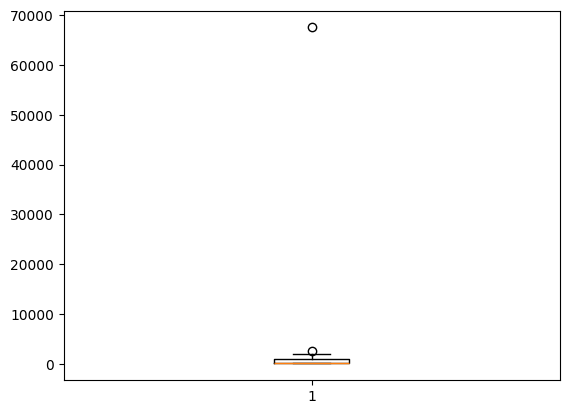

In [23]:
plt.boxplot(filtered_df_by_company_location["company_location"].value_counts().values)

{'whiskers': [<matplotlib.lines.Line2D at 0x1db3225b9d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1db3225bc50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db3225b890>],
 'medians': [<matplotlib.lines.Line2D at 0x1db3225bed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db3329c050>],
 'means': []}

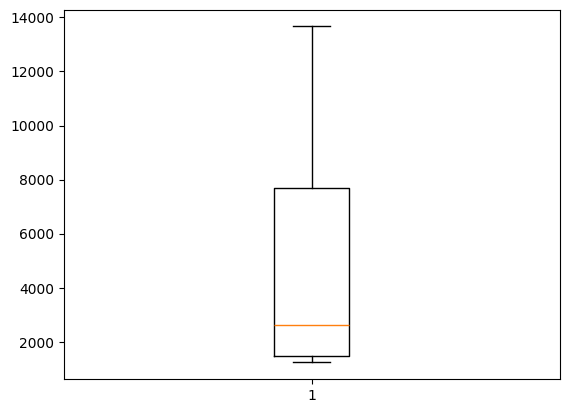

In [24]:
plt.boxplot(filtered_df_by_company_location["job_title"].value_counts().values)

In [25]:
df_without_usesless_columns = filtered_df_by_company_location.copy()
df_without_usesless_columns.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [26]:
df_without_usesless_columns = df_without_usesless_columns.drop(columns=["salary_currency", "salary"], axis=1)


In [27]:
df_without_usesless_columns.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

{'whiskers': [<matplotlib.lines.Line2D at 0x1db332cb390>,
 'caps': [<matplotlib.lines.Line2D at 0x1db332cb610>,
 'boxes': [<matplotlib.lines.Line2D at 0x1db332cb250>],
 'medians': [<matplotlib.lines.Line2D at 0x1db332cb890>],
 'fliers': [<matplotlib.lines.Line2D at 0x1db332cb9d0>],
 'means': []}

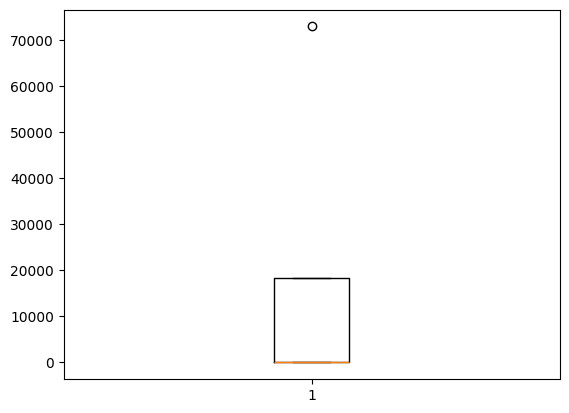

In [28]:
plt.boxplot(df_without_usesless_columns["employment_type"].value_counts().values)

In [29]:
df_without_usesless_columns.columns
df_without_usesless_columns["employment_type"].value_counts()

employment_type
FT    73021
PT      148
CT      141
FL        1
Name: count, dtype: int64

In [30]:
df_emptype = df_without_usesless_columns.copy()


In [31]:
df_emptype = df_without_usesless_columns[df_without_usesless_columns["employment_type"] == "FT"].copy()
df_emptype.head()
df_emptype.columns
df_emptype["employment_type"].value_counts()

employment_type
FT    73021
Name: count, dtype: int64

In [32]:
df_without_employment_type = df_emptype.drop(columns=["employment_type"], axis=1)
df_without_employment_type.columns

Index(['work_year', 'experience_level', 'job_title', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [33]:
df_without_employment_type.columns
df_without_employment_type["work_year"].value_counts()

work_year
2024    48950
2025    15353
2023     7145
2022     1413
2021      121
2020       39
Name: count, dtype: int64

In [34]:
df_work_year = df_without_employment_type.copy()
df_work_year = df_work_year[df_work_year["work_year"].map(df_work_year["work_year"].value_counts()) >= 1000].copy()
df_work_year.columns
df_work_year["work_year"].value_counts()

work_year
2024    48950
2025    15353
2023     7145
2022     1413
Name: count, dtype: int64

In [35]:
df_work_year.columns
df_work_year["remote_ratio"].value_counts()

remote_ratio
0      58017
100    14780
50        64
Name: count, dtype: int64

In [36]:
df_remote_ratio = df_work_year.copy()
df_remote_ratio = df_remote_ratio[df_remote_ratio["remote_ratio"].map(df_remote_ratio["remote_ratio"].value_counts()) >= 1000].copy()
df_remote_ratio.columns
df_remote_ratio["remote_ratio"].value_counts()

remote_ratio
0      58017
100    14780
Name: count, dtype: int64

In [37]:
df_remote_ratio.columns
df_remote_ratio["job_title"].value_counts()

job_title
Data Scientist               13513
Data Engineer                11016
Software Engineer            10045
Data Analyst                  8719
Machine Learning Engineer     6515
Engineer                      5740
Manager                       3786
Research Scientist            2618
Analyst                       2257
Applied Scientist             1806
Data Architect                1522
Analytics Engineer            1410
Product Manager               1374
Associate                     1241
Research Engineer             1235
Name: count, dtype: int64

In [38]:
df_remote_ratio.columns
df_remote_ratio["employee_residence"].value_counts() #Anotacion para mateo

employee_residence
US    67181
CA     2541
GB     1884
AU      216
ES      166
LT      164
DE      159
FR      144
NL      140
AT      133
IN       69
Name: count, dtype: int64

In [39]:
df_remote_ratio.columns
df_remote_ratio["experience_level"].value_counts()

experience_level
SE    43659
MI    21363
EN     6542
EX     1233
Name: count, dtype: int64

In [40]:
df_remote_ratio.columns
df_remote_ratio["company_size"].value_counts() #Anotacion para mateo

company_size
M    70934
L     1821
S       42
Name: count, dtype: int64

In [41]:
df_company_size = df_remote_ratio.copy()
df_company_size = df_company_size[df_company_size["company_size"].map(df_company_size["company_size"].value_counts()) >= 1000].copy()
df_company_size.columns
df_company_size["company_size"].value_counts() 

company_size
M    70934
L     1821
Name: count, dtype: int64

In [42]:
df_company_size.columns
df_company_size["company_location"].value_counts()

company_location
US    67163
CA     2538
GB     1882
AU      215
LT      164
ES      163
DE      153
FR      142
NL      137
AT      132
IN       66
Name: count, dtype: int64

In [43]:
df_company_location = df_company_size.copy()
df_company_location = df_company_location[df_company_location["company_location"].map(df_company_location["company_location"].value_counts()) >= 100].copy()
df_company_location.columns
df_company_location["company_location"].value_counts()

company_location
US    67163
CA     2538
GB     1882
AU      215
LT      164
ES      163
DE      153
FR      142
NL      137
AT      132
Name: count, dtype: int64

In [44]:
df_company_location.columns
df_company_location["job_title"].value_counts()

job_title
Data Scientist               13492
Data Engineer                11000
Software Engineer            10039
Data Analyst                  8698
Machine Learning Engineer     6502
Engineer                      5738
Manager                       3784
Research Scientist            2611
Analyst                       2257
Applied Scientist             1806
Data Architect                1518
Analytics Engineer            1409
Product Manager               1366
Associate                     1238
Research Engineer             1231
Name: count, dtype: int64

In [45]:
df_company_location.columns

Index(['work_year', 'experience_level', 'job_title', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [ ]:
df_company_location

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Copy the dataset
df = df_company_location.copy()

# 1. Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# 2. Apply OneHotEncoding to categorical columns
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # Fixed parameter
X_encoded = encoder.fit_transform(X[categorical_cols])

# 3. Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# 4. Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 5. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Make predictions
y_pred = model.predict(X_test)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

# 8. Make a prediction with new data
new_data = np.array([[2026, 'MI', 'Data Scientist', 'US', 0, 'US', 'L']])  # Replace with actual values

# Convert new data to DataFrame
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size'])

# Apply the same encoding transformation
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate with numerical features
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), new_data_encoded_df], axis=1)

# Make prediction
predicted_value = model.predict(new_data_final)
print(f"Predicted Value: {predicted_value}")


Mean Squared Error: 4006846414.812584
R² Score: 0.2410208438462914
Predicted Value: [150845.3298609]


In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Copy dataset
df = df_company_location.copy()

# Function to remove outliers based on IQR for each experience level
def remove_outliers_by_experience(df, column='salary_in_usd', group_by='experience_level'):
    df_filtered = df.copy()
    
    for level in df[group_by].unique():
        subset = df[df[group_by] == level]
        
        Q1 = subset[column].quantile(0.25)  # 25th percentile
        Q3 = subset[column].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers only within this experience level
        df_filtered = df_filtered.drop(df_filtered[(df_filtered[group_by] == level) & 
                                                   ((df_filtered[column] < lower_bound) | (df_filtered[column] > upper_bound))].index)

    return df_filtered

# Apply outlier removal
df = remove_outliers_by_experience(df)

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# Apply OneHotEncoding to categorical columns
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # Fixed sklearn parameter
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Square root to get RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")


Mean Squared Error: 2784047821.2151985
Root Mean Squared Error: 52764.076995766714
R² Score: 0.28676323187779784


In [49]:
df_remote_ratio_delete = df_company_location.copy()
df_remote_ratio_delete = df_remote_ratio_delete[df_remote_ratio_delete["remote_ratio"].map(df_remote_ratio_delete["remote_ratio"].value_counts()) > 20000].copy()
df_remote_ratio_delete.columns
df_remote_ratio_delete = df_remote_ratio_delete.drop(columns=["remote_ratio"], axis=1)
df_remote_ratio_delete.columns

Index(['work_year', 'experience_level', 'job_title', 'salary_in_usd',
       'employee_residence', 'company_location', 'company_size'],
      dtype='object')

In [52]:
df_remote_ratio_delete['job_title'].value_counts()

job_title
Data Scientist               10170
Software Engineer             8505
Data Engineer                 8316
Data Analyst                  6570
Machine Learning Engineer     5265
Engineer                      4919
Manager                       3184
Research Scientist            2364
Analyst                       1849
Applied Scientist             1400
Data Architect                1162
Product Manager               1142
Research Engineer             1132
Associate                     1066
Analytics Engineer             922
Name: count, dtype: int64

In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Copy dataset
df = df_remote_ratio_delete.copy()

# Function to remove outliers based on IQR for each experience level
def remove_outliers_by_experience(df, column='salary_in_usd', group_by='experience_level'):
    df_filtered = df.copy()
    
    for level in df[group_by].unique():
        subset = df[df[group_by] == level]
        
        Q1 = subset[column].quantile(0.25)  # 25th percentile
        Q3 = subset[column].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers only within this experience level
        df_filtered = df_filtered.drop(df_filtered[(df_filtered[group_by] == level) & 
                                                   ((df_filtered[column] < lower_bound) | (df_filtered[column] > upper_bound))].index)

    return df_filtered

# Apply outlier removal
df = remove_outliers_by_experience(df)

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence',  'company_location', 'company_size']]
y = df['salary_in_usd']

# Apply OneHotEncoding to categorical columns
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # Fixed sklearn parameter
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Square root to get RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

Mean Squared Error: 2973540839.067288
Root Mean Squared Error: 54530.18282627785
R² Score: 0.28136855097999214


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Copy dataset
df = df_company_location.copy()

# Function to remove outliers based on IQR for each experience level
def remove_outliers_by_experience(df, column='salary_in_usd', group_by='experience_level'):
    df_filtered = df.copy()
    
    for level in df[group_by].unique():
        subset = df[df[group_by] == level]
        
        Q1 = subset[column].quantile(0.25)  # 25th percentile
        Q3 = subset[column].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Remove outliers only within this experience level
        df_filtered = df_filtered.drop(df_filtered[(df_filtered[group_by] == level) & 
                                                   ((df_filtered[column] < lower_bound) | 
                                                    (df_filtered[column] > upper_bound))].index)

    return df_filtered

# Apply outlier removal
df = remove_outliers_by_experience(df)

# Apply log transformation to salary
df['salary_in_usd'] = np.log1p(df['salary_in_usd'])

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 
        'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# Apply OneHotEncoding to categorical columns
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # Encoding categorical variables
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_final_scaled, y, test_size=0.2, random_state=42)

# Train RandomForestRegressor (better for non-linear relationships)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # Square root to get RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Make a new prediction
new_data = np.array([[2026, 'MI', 'Data Scientist', 'US', 0, 'US', 'M']])  # Replace with real values

# Encode and scale new data
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 
                                              'employee_residence', 'remote_ratio', 
                                              'company_location', 'company_size'])
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)
new_data_scaled = scaler.transform(new_data_final)

# Predict and reverse log transformation
predicted_salary = np.expm1(model.predict(new_data_scaled))
print(f"Predicted Salary: ${predicted_salary[0]:,.2f}")


Mean Squared Error: 0.118077661495321
Root Mean Squared Error: 0.3436243028298799
R² Score: 0.37154014728488316
Predicted Salary: $123,421.85


In [57]:
new_data = np.array([[2040, 'MI', 'Data Scientist', 'US', 0, 'US', 'M']])  # Replace with real values

# Encode and scale new data
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 
                                              'employee_residence', 'remote_ratio', 
                                              'company_location', 'company_size'])
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)
new_data_scaled = scaler.transform(new_data_final)

# Predict and reverse log transformation
predicted_salary = np.expm1(model.predict(new_data_scaled))
print(f"Predicted Salary: ${predicted_salary[0]:,.2f}")


Predicted Salary: $123,421.85


In [71]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Copy the dataset
df = df_company_location.copy()

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 
        'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# One-Hot Encoding for categorical features
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 
                    'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Ensure no NaNs exist
X_final = X_final.fillna(0)
y = y.fillna(0)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Train Random Forest Model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Make a prediction with new data (Fix: Removed extra value)
new_data = np.array([[2026, 'MI', 'Data Scientist', 'US', 0, 'US', 'M']])

# Convert to DataFrame
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 
                                              'employee_residence', 'remote_ratio', 
                                              'company_location', 'company_size'])

# Encode new data
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate with numerical features
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)

# Ensure the new data matches the training feature order
new_data_final = new_data_final.reindex(columns=X_final.columns, fill_value=0)

# Predict
predicted_value = model.predict(new_data_final)
print(f"Predicted Salary: {predicted_value}")


Mean Squared Error: 3918604056.8058186
Root Mean Squared Error: 62598.75443493919
R² Score: 0.25773576213449856
Predicted Salary: [132939.32931279]


In [72]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Copy the dataset
df = df_company_location.copy()

# Log-transform the salary
df['salary_in_usd'] = np.log1p(df['salary_in_usd'])

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 
        'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# One-Hot Encoding for categorical features
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 
                    'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Ensure no NaNs exist
X_final = X_final.fillna(0)
y = y.fillna(0)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Hyperparameter tuned Random Forest model
model = RandomForestRegressor(
    n_estimators=500,       # More trees for better learning
    max_depth=20,           # Limits tree depth to prevent overfitting
    min_samples_split=5,    # Avoids splits with too few samples
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Convert predictions back to original scale
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

# Evaluate Model
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred_original)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Make a prediction with new data
new_data = np.array([[2026, 'MI', 'Data Scientist', 'US', 0, 'US', 'M']])
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 
                                              'employee_residence', 'remote_ratio', 
                                              'company_location', 'company_size'])

# Encode new data
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), new_data_encoded_df], axis=1)

# Ensure the new data matches the training feature order
new_data_final = new_data_final.reindex(columns=X_final.columns, fill_value=0)

# Predict and revert log transformation
predicted_log_salary = model.predict(new_data_final)
predicted_salary = np.expm1(predicted_log_salary)
print(f"Predicted Salary: {predicted_salary}")

Mean Squared Error: 4024691536.026128
Root Mean Squared Error: 63440.45661899138
R² Score: 0.23764061070582287
Predicted Salary: [123767.66025038]


In [73]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Copy the dataset
df = df_company_location.copy()

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 
        'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# Normalize salaries
y_scaler = StandardScaler()
y = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Target Encoding for job_title (mean salary per job)
X['job_title_encoded'] = X['job_title'].map(df.groupby('job_title')['salary_in_usd'].mean())
X.drop(columns=['job_title'], inplace=True)

# One-Hot Encoding for categorical features
categorical_cols = ['experience_level', 'employee_residence', 'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Add polynomial features for work_year
poly = PolynomialFeatures(degree=2, include_bias=False)
work_year_poly = poly.fit_transform(X_final[['work_year']])
work_year_poly_df = pd.DataFrame(work_year_poly, columns=poly.get_feature_names_out(['work_year']))
X_final = pd.concat([X_final.drop(columns=['work_year']).reset_index(drop=True), work_year_poly_df], axis=1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Hyperparameter tuning for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(rf, param_grid, n_iter=10, cv=3, n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Best Params: {random_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Feature Importance Analysis
feature_importances = pd.Series(best_model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
print("Top Features:")
print(feature_importances.head(10))

# Make a prediction with new data
new_data = np.array([[2026, 'MI', 'US', 0, 'US', 'M']])
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'employee_residence', 
                                              'remote_ratio', 'company_location', 'company_size'])

# Encode new data
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))
new_data_df['job_title_encoded'] = df.groupby('job_title')['salary_in_usd'].mean().get('MI', df['salary_in_usd'].mean())
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)
new_data_final = new_data_final.reindex(columns=X_final.columns, fill_value=0)

# Predict and reverse normalize
predicted_value = best_model.predict(new_data_final)
predicted_salary = y_scaler.inverse_transform(predicted_value.reshape(-1, 1))
print(f"Predicted Salary: {predicted_salary.flatten()[0]}")

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Mean Squared Error: 0.7457488099037165
Root Mean Squared Error: 0.863567490068794
R² Score: 0.25867299634378316
Top Features:
job_title_encoded        0.620416
experience_level_SE      0.098775
company_location_US      0.075388
experience_level_EN      0.043371
experience_level_EX      0.041999
employee_residence_US    0.027051
remote_ratio             0.021586
experience_level_MI      0.012161
work_year^2              0.011399
work_year                0.011218
dtype: float64
Predicted Salary: 154510.36433887473


In [74]:
new_data = np.array([[2027, 'MI', 'US', 0, 'US', 'M']])
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'employee_residence', 
                                              'remote_ratio', 'company_location', 'company_size'])

# Encode new data
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))
new_data_df['job_title_encoded'] = df.groupby('job_title')['salary_in_usd'].mean().get('MI', df['salary_in_usd'].mean())
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)
new_data_final = new_data_final.reindex(columns=X_final.columns, fill_value=0)

# Predict and reverse normalize
predicted_value = best_model.predict(new_data_final)
predicted_salary = y_scaler.inverse_transform(predicted_value.reshape(-1, 1))
print(f"Predicted Salary: {predicted_salary.flatten()[0]}")

Predicted Salary: 154510.36433887473


In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV

# Copy the dataset
df = df_company_location.copy()

# Transform work_year to be relative to 2021
df["work_year"] = df["work_year"] - 2021

# Normalize salary
scaler = MinMaxScaler()
df['salary_in_usd'] = scaler.fit_transform(df[['salary_in_usd']])

# Select features and target variable
X = df[['work_year', 'experience_level', 'job_title', 'employee_residence', 
        'remote_ratio', 'company_location', 'company_size']]
y = df['salary_in_usd']

# One-Hot Encoding for categorical features
categorical_cols = ['experience_level', 'job_title', 'employee_residence', 
                    'company_location', 'company_size']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame and concatenate with numerical features
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols))
X_final = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), X_encoded_df], axis=1)

# Ensure no NaNs exist
X_final = X_final.fillna(0)
y = y.fillna(0)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Hyperparameter tuning with RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(rf, param_distributions=param_grid, n_iter=10, cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best Model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Best Params: {random_search.best_params_}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Feature Importance
feature_importances = pd.Series(best_model.feature_importances_, index=X_final.columns)
top_features = feature_importances.nlargest(10)
print("Top Features:")
print(top_features)

# Make a prediction with new data (Adjusted work_year)
new_data = np.array([[2026 - 2021, 'MI', 'Data Scientist', 'US', 0, 'US', 'M']])  # Adjust work_year

# Convert to DataFrame
new_data_df = pd.DataFrame(new_data, columns=['work_year', 'experience_level', 'job_title', 
                                              'employee_residence', 'remote_ratio', 
                                              'company_location', 'company_size'])

# Encode new data
new_data_encoded = encoder.transform(new_data_df[categorical_cols])
new_data_encoded_df = pd.DataFrame(new_data_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate with numerical features
new_data_final = pd.concat([new_data_df.drop(columns=categorical_cols).reset_index(drop=True), 
                            new_data_encoded_df], axis=1)

# Ensure the new data matches the training feature order
new_data_final = new_data_final.reindex(columns=X_final.columns, fill_value=0)

# Predict (Denormalizing salary)
predicted_value = best_model.predict(new_data_final)
predicted_salary = scaler.inverse_transform([[predicted_value[0]]])[0][0]

print(f"Predicted Salary: {predicted_salary}")


Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15}
Mean Squared Error: 0.0064726429705292115
Root Mean Squared Error: 0.0804527374955583
R² Score: 0.2579305482869294
Top Features:
job_title_Data Analyst                 0.292749
experience_level_SE                    0.152828
company_location_US                    0.070465
job_title_Analyst                      0.045006
job_title_Data Engineer                0.044569
employee_residence_US                  0.038947
job_title_Data Scientist               0.036256
experience_level_EX                    0.033841
job_title_Machine Learning Engineer    0.030008
job_title_Research Scientist           0.025996
dtype: float64
Predicted Salary: 133780.2776661197
